In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib
#matplotlib.use('Agg')
import random
from pytorch_lightning.loggers import TensorBoardLogger
from tqdm import tqdm
import json
import imageio
# import shap
import numpy

import os
import torch
from torch.utils.data import TensorDataset, DataLoader
import torchvision.transforms as T
import warnings
import pickle
warnings.filterwarnings("ignore")
import sys
sys.path.append('..')

from src.data_assemble.wrap_data import *
from src.models.WindCNN import *
from src.data_assemble.wrap_data import *

# %load_ext tensorboard
# %tensorboard --logdir lightning_logs/
random.seed(24)

In [2]:
path_to_data = os.path.join('..', 'data', 'stash', 'WindProject', 'nn_data_grid_inference_kk_extended')
st_split_dict = train_val_test_split(path_to_data, train = 0.5, val = 0.25, test = 0.25, verbose = True)
path_to_dump = os.path.join('..', 'data', 'stash', 'WindProject', 'nn_data_grid_inference_kk_extended')
X, y = extract_splitted_data(path_to_dump, st_split_dict)

{'Train': ['(6, 21)', '(12, 26)', '(3, 16)', '(14, 26)', '(16, 23)', '(14, 4)', '(4, 5)', '(14, 12)', '(12, 9)', '(19, 28)', '(20, 17)', '(10, 23)', '(4, 7)', '(17, 24)', '(14, 21)', '(10, 14)', '(5, 9)', '(4, 21)', '(15, 8)', '(9, 7)', '(10, 10)', '(15, 4)', '(15, 12)', '(12, 7)', '(11, 19)', '(17, 13)', '(18, 17)', '(15, 15)', '(18, 21)', '(9, 20)', '(13, 23)', '(18, 8)', '(20, 4)', '(11, 27)', '(10, 25)', '(12, 3)', '(19, 13)', '(3, 18)', '(6, 27)', '(6, 26)', '(10, 24)', '(13, 7)', '(7, 11)', '(19, 11)', '(8, 19)', '(9, 12)', '(17, 12)', '(12, 21)', '(14, 20)', '(14, 11)', '(14, 24)', '(16, 17)', '(13, 14)', '(19, 22)', '(18, 13)', '(17, 22)', '(10, 26)', '(13, 11)', '(3, 14)', '(4, 10)', '(7, 20)', '(5, 8)', '(14, 23)', '(18, 12)', '(8, 21)', '(8, 7)', '(20, 6)', '(5, 14)', '(9, 15)', '(16, 8)', '(3, 9)', '(16, 14)', '(10, 17)', '(6, 24)', '(13, 12)', '(18, 9)', '(15, 16)', '(5, 7)', '(13, 20)', '(6, 20)', '(4, 24)', '(14, 15)', '(15, 19)', '(10, 20)', '(13, 18)', '(5, 11)', '(19,

In [3]:
batch_size = 1024
with open(os.path.join('..', 'conf', 'conv_config.json')) as fs:
    args = json.load(fs)

In [4]:
logger = TensorBoardLogger(save_dir='../logs/wind', name='windnet')
trainer = pl.Trainer(max_epochs=50,
                    gpus='1',
                    benchmark=True,
                    check_val_every_n_epoch=1,
)

dm = WindDataModule(X=X, y=y, batch_size=batch_size, downsample=False)
model = WindNetPL(args)

# chk_path = "./lightning_logs/version_13/checkpoints/epoch=35-step=288.ckpt"
chk_path = "lightning_logs/version_12"
chk_path = os.path.join(chk_path, "checkpoints", os.listdir(os.path.join(chk_path, "checkpoints"))[0])
model2 = WindNetPL.load_from_checkpoint(chk_path, args=args)
model2.eval()

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


WindNetPL(
  (net): WindNet(
    (conv1): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (conv2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc): Linear(in_features=800, out_features=2, bias=True)
    (net): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
      (3): ReLU()
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Flatten(start_dim=1, end_dim=-1)
      (6): Linear(in_features=800, out_features=2, bias=True)
      (7): LogSoftmax(dim=None)
    )
  )
  (accuracy): Accuracy()
  (AUROC): AUROC()
  (precision_m): Precision()
  (recall): Recall()
  (F1): F1Score()
  (conf_matrix): ConfusionMatrix()
  (stats_scores): Stat

# Shap

In [5]:
# trainer.test(model2, dm)

In [6]:
# batch = next(iter(dm.test_dataloader()))
# images, _ = batch

# background = images[:100]
# test_images = images[100:103]

# e = shap.DeepExplainer(model2, background)
# shap_values = e.shap_values(test_images)

In [7]:
# features = ['elev', 'pr', 'tasmax', 'tasmin', 'wind']
# for i in range(len(features)):
#     print(features[i], abs((torch.mean(torch.tensor(shap_values[0]), dim=[0, 2, 3])[i]).numpy()) + (torch.mean(torch.tensor(shap_values[1]), dim=[0, 2, 3])[i]).numpy() )

In [8]:
# shap_numpy = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_values]
# test_numpy = np.swapaxes(np.swapaxes(test_images.numpy(), 1, -1), 1, 2)
# shap.image_plot(shap_numpy, -test_numpy)

# Inferring on each pixel

In [6]:
start_x = X['Grid'][0].time[1825]   # 2798 - '2023-09-01'
end_x = X['Grid'][0].time[2220]        # 2858 - '2023-10-31'
print('Start date:', start_x)
print('End date:', end_x)

Start date: <xarray.DataArray 'time' ()>
array('2021-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2021-01-01
End date: <xarray.DataArray 'time' ()>
array('2022-01-31T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2022-01-31


In [7]:
# path_to_data = os.path.join('data', 'nn_data_grid_inference')
path_to_data = os.path.join('..', 'data', 'stash', 'WindProject', 'nn_data_grid_inference_kk_extended')
grid_inference_ = {}
coord = {}

for i, curr_pix in tqdm(enumerate(os.listdir(path_to_data))):
    X, y = extract_splitted_data(path_to_data, {'Grid': [curr_pix]}, return_xarray=True)
    
    coord[curr_pix] = [X['Grid'][0].lat[2], X['Grid'][0].lon[2]] 
    X['Grid'] = X['Grid'][0].loc[start_x : end_x].data

    X_grid_t = torch.tensor(X["Grid"], device=model2.device).double()
    inference = model2(dm.transform(X_grid_t)).detach().cpu().numpy()
    # grid_inference_[curr_pix] = inference
    grid_inference_[curr_pix] = torch.exp(torch.tensor(inference))
    
X, y = extract_splitted_data(path_to_data, {'Grid': [curr_pix]}, return_xarray = True)
time_axis = X['Grid'][0].loc[start_x : end_x].time.data
# with open('../data/stash/WindProject/grid_inference_florida_fixed.npy','wb') as f:
#         pickle.dump(grid_inference_, f)

468it [02:20,  3.33it/s]


In [14]:
# path_to_data = os.path.join('..', 'data', 'stash', 'WindProject', 'nn_data_grid_inference_florida_fixed')
# coord = {}
# for i, curr_pix in tqdm(enumerate(os.listdir(path_to_data))):
#     X, y = extract_splitted_data(path_to_data, {'Grid': [curr_pix]}, return_xarray = True)
#     coord[curr_pix] = [X['Grid'][0].lat[2], X['Grid'][0].lon[2]]
# time_axis = X['Grid'][0].time.data
# with open('../data/stash/WindProject/grid_inference_florida.npy', "rb") as f:
#         grid_inference_ = pickle.load(f)

1260it [00:34, 36.52it/s]


In [8]:
grid_inference = {}
for k in grid_inference_.keys():
    try:
        k1, k2 = k[1:-1].split(', ')
        k1 = int(k1)
        
        k2 = int(k2)
        grid_inference[(k1, k2)] = grid_inference_[k]
    except AttributeError:
        pass
del grid_inference_

In [9]:
keys = list(grid_inference.keys())
sorted_tmp = sorted(keys, key=lambda x: x[0])
shift_x = sorted_tmp[0][0] + 1
max_x = sorted_tmp[-1][0] + shift_x
sorted_tmp = sorted(keys, key=lambda x: x[1])
shift_y = sorted_tmp[0][1] + 1
max_y = sorted_tmp[-1][1] + shift_y
some_key = keys[0]
grid = np.zeros((grid_inference[some_key].shape[0], max_x, max_y))

for k in grid_inference.keys():
    grid[:, k[0], k[1]] = grid_inference[k][:, 1]

In [13]:
# start_date = pd.to_datetime('2006-01-01')
# start_date = pd.to_datetime('2021-01-01')
# str(start_date + pd.DateOffset(1) * 31)
# import csv
# with open('wind20_2021_2030.csv', 'w') as csvfile: 
#     write = csv.writer(csvfile) 
#     # write.writerow(np_array_col) 
#     write.writerows(grid)
# np.save('wind20_2021_2030.npy', grid)

# Optional exponential smoothing

In [35]:
exp_smooth = True
if exp_smooth:
    grid_new = np.zeros_like(grid)
    for i in range(grid.shape[0]):
        grid_new[i,:,:] = ewma_vectorized_2d(data=grid[i,:,:], alpha=2, axis=1)
        grid_new[i,:,:] = ewma_vectorized_2d(data=grid_new[i,:,:], alpha=2, axis=0)
else:
    grid_new = grid

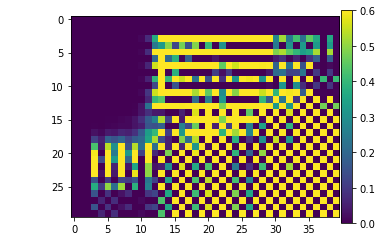

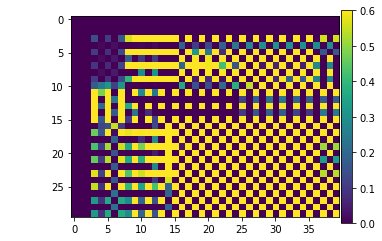

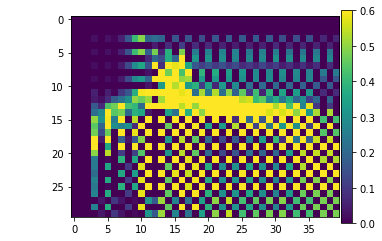

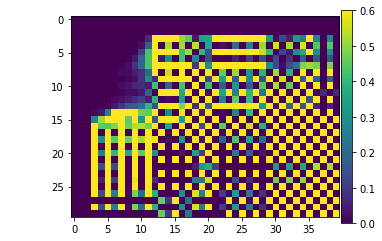

In [36]:
# X = np.arange(36.5, 42.0, 0.5)#[36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5]
# Y = np.arange(43.5, 47.5, 0.5)[::-1]#[47.0, 46.5, 46.0, 45.5, 45.0, 44.5, 44.0, 43.5]
X=X_full
Y=Y_full

for t in list(range(grid_new.shape[0]))[::100]:
    data = grid_new[t, :, :]
    fig = plt.figure(figsize=(7, 3.7))

    ax = fig.add_subplot(111)
    # ax.set_title('t = ' + str(start_date + pd.DateOffset(1) * t))
    plt.imshow(data,vmin=0, vmax=0.6)
    # plt.colorbar()
    ax.set_aspect('equal')
    # ax.set_xticks(np.arange(0,grid_new.shape[2],2), labels=X)
    # ax.set_yticks(np.arange(grid_new.shape[1]-1,-1,-2), labels=Y)

    cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
    cax.get_xaxis().set_visible(False)
    cax.get_yaxis().set_visible(False)
    cax.set_frame_on(False)
    plt.colorbar(orientation='vertical')
    # plt.savefig('tmp_dump/' + str(t) + '.png')
    # plt.show()

In [16]:
# images = []
# filenames = [os.path.join('tmp_dump', str(f) + '.png') for f in list(range(grid.shape[0]))[::100]]
# for filename in filenames:
#     images.append(imageio.imread(filename))
# imageio.mimsave('tmp_dump/wind_prob_maps.gif', images, duration=0.5)

# Map visualisation

In [10]:
keyss = coord.keys()
X_full = []
Y_full = []
for k in keyss:
    Y_full.append(float(coord[k][0].data))
    X_full.append(float(coord[k][1].data))
Y_full = np.array(list(set(Y_full)))
X_full = np.array(list(set(X_full)))
day_interval = 1
# with open('../data/stash/WindProject/grid_florida.npy', "rb") as f:
#         grid = pickle.load(f)

In [11]:
dff = map_to_pandas(grid=grid, x_axis=X_full, y_axis=Y_full, t_axis=time_axis, start_date='', day_interval=day_interval)
dates = np.unique(dff.date)

100%|█| 396/396 [00:37<00:00


In [61]:
plotdf = dff[dff['date']==dates[378]][['lon', 'lat', 'value']]

numpy.datetime64('2022-01-14T00:00:00.000000000')

In [40]:
# KK
# dates[263] - 09-09-21
# dates[302] - 30-10-21
# dates[378] - 14-01-22
# Florida
# dates[20] - 21.08.22
# dates[51] - 21.09.22
# dates[81] - 21.10.22
# plotdf.to_csv('../data/stash/WindProject/try.csv')

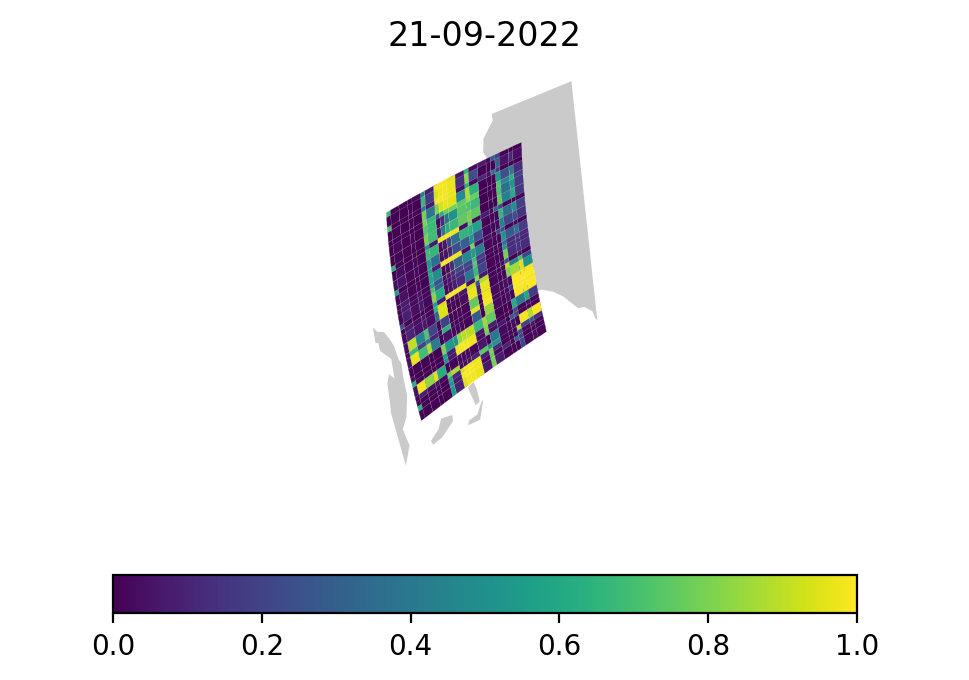

In [40]:
plot_map(df[df['date']==dates[51]], 'value', part_world_to_plot='Florida', vmin=0, vmax=1, text = '21-09-2022')

## Saving each day
~ 30-60 minutes

In [24]:
column = 'value'

vmin = 0
vmax = 0.6

name = 0
if not os.path.exists('anim_future'):
    os.makedirs('anim_future')
for t in list(range(grid.shape[0]))[::day_interval]:
    date = str(start_date + pd.DateOffset(1) * t)
    plot_map(df[df['date'] == date], column, part_world_to_plot='KK', vmin=vmin, vmax=vmax, 
             img_path=f'anim_future/{name}.jpg', text = date,
             show=False)
    name+=1
    plt.close()

NameError: name 'start_date' is not defined

# Make .h264 video from generated images

# Picture for Paper

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
import matplotlib as mpl
%matplotlib inline
# ffmpeg -framerate 1 -pattern_type glob -i '*.png' -c:v libx264 -r 30 -pix_fmt yuv420p out.mp4 # 1 секунда между кадрами
### ffmpeg -framerate 30 -pattern_type glob -i '*.png' -c:v libx264 -pix_fmt yuv420p out.mp4 мгновенно

<AxesSubplot:>

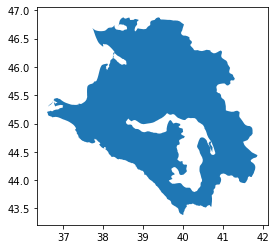

In [14]:
# Here you can choose Russian region to draw
rus_bnd_gdf = gpd.read_file('../data/stash/WindProject/geo.json')
rus_bnd_gdf[(rus_bnd_gdf.NAME_1 == 'Krasnodar')].plot() # (rus_bnd_gdf.NAME_1 == 'Rostov') | (rus_bnd_gdf.NAME_1 == 'Belgorod')

In [41]:
df=plotdf
# df.lon = df.lon - 360 # Uncomment it if you work with America (where longitude is negative)

df["Coordinates"] = list(zip(df.lon, df.lat))
df["Coordinates"] = df["Coordinates"].apply(Point)
gdf = gpd.GeoDataFrame(df, geometry="Coordinates")

state_df = rus_bnd_gdf[(rus_bnd_gdf.NAME_1 == 'Krasnodar')]
# or uncomment below to draw for Florida
# state_df = gpd.read_file("https://datascience.quantecon.org/assets/data/cb_2016_us_state_5m.zip")
# state_df = state_df.query("NAME == 'Florida'")

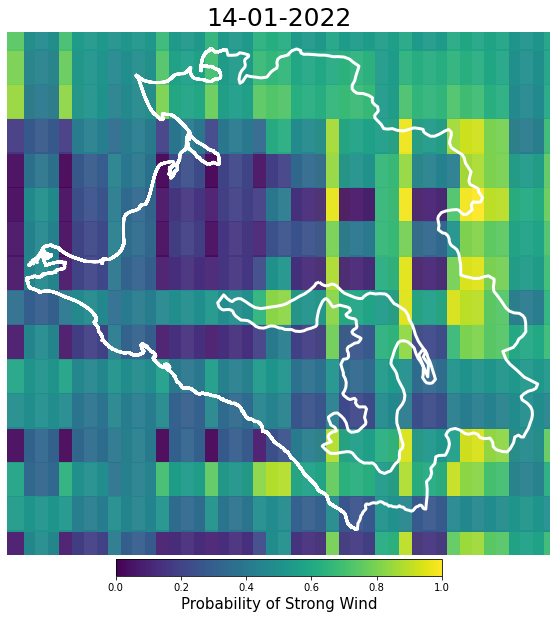

In [42]:
fig, gax = plt.subplots(figsize=(10, 10))
g = gdf.plot(ax=gax, c=df['value'], marker='s', markersize=1200, alpha = 0.95)
state_df.plot(ax=gax, edgecolor="white", color="None", lw=3, alpha = 1)

# Add colorbar
cmap = gax.collections[-1].colorbar
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, orientation="horizontal", fraction=0.03, pad=0.009, ).set_label(label='Probability of Strong Wind',size=15)  #,weight='bold'  
gax.axis('off')
plt.xlim(36.4, 42.)
plt.ylim(43.2, 47)
plt.title('14-01-2022', fontsize=25)
# plt.savefig('KK_14-01-2022.png')
plt.show() 

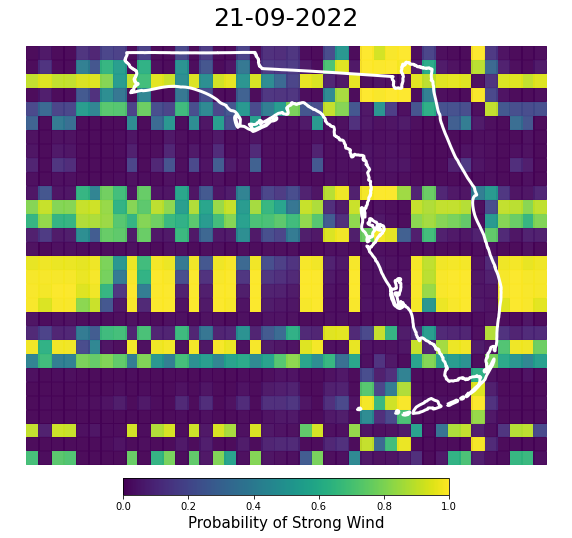

In [26]:
fig, gax = plt.subplots(figsize=(10, 10))
g = gdf.plot(ax=gax, c=df['value'], marker='s', markersize=169, alpha = 0.95)
state_df.plot(ax=gax, edgecolor="white", color="None", lw=3, alpha = 1)

# Add colorbar
cmap = gax.collections[-1].colorbar
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, orientation="horizontal", fraction=0.03, pad=0.0005, ).set_label(label='Probability of Strong Wind',size=15)  #,weight='bold'  
gax.axis('off')
plt.title('21-09-2022', fontsize=25)
# plt.savefig('Florida_Paper_with_white_borders.png')
plt.show() 

Попробовать применить сглаживание (smoothing, должен быть флаг True False) DONE

Send pictures to Ilya :  DONE

Florida  21.09.2022, 21.08.2022, 21.10.2022 , 21.09.2023   DONE
  
KK, Rostov, Belgorod dates from paper  DONE

Как увеличить разрешение (т.е. уменьшить квадратики и увеличить их количество) картинок????

## Remake violin plots for paper

In [44]:
df = pd.read_csv('../data/stash/WindProject/weather_stations/data_meteo_full.csv')

AttributeError: module 'seaborn' has no attribute 'xlim'

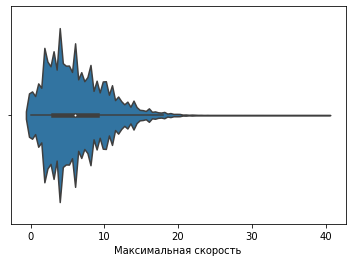

In [55]:
alt_st = ['Камень-на-Оби', 'Барнаул', 'Славгород', 'Ребриха', 'Бийск-Зональная', 'Рубцовск', 'Змеиногорск', 'Солонешное']
altais = df[df['Название метеостанции'].isin(alt_st)]
altais['Дата'] = pd.to_datetime(altais['Дата'])
final = altais[(altais['Дата'] > pd.to_datetime('2000-01-01')) & (altais['Дата'] < pd.to_datetime('2015-01-01'))]
final = final[final['Максимальная скорость'] < 30]
sns.violinplot(x=final['Максимальная скорость'])

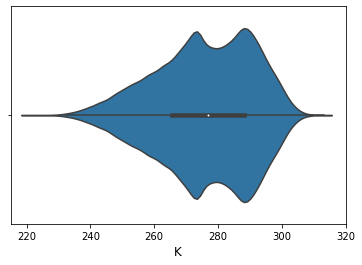

In [72]:
temp = (final['Температура воздуха по сухому терм-ру'] + 273.15)
g= sns.violinplot(x=temp)
g.set(xlim=(215, 320));
g.set_xlabel("K", fontsize=12);
# fig = g.get_figure()
# fig.savefig("stations_temperature.png") 

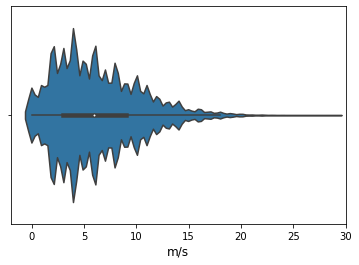

In [87]:
g= sns.violinplot(x=final['Максимальная скорость'])
g.set(xlim=(-2, 30));
g.set_xlabel("m/s", fontsize=12);
# fig = g.get_figure()
# fig.savefig("stations_windspeed.png") 